# Varian 01 — Single Layer (Baseline Linier)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/01_single_layer.ipynb)

**Anggota yang mengerjakan:** _Anggota 1_

---

## 🏗️ Arsitektur
Single-layer network: **input langsung ke output**, tanpa hidden layer. Ini setara dengan logistic regression multi-kelas (sesuai sub-bab 2.2 di slide).

## ⚡ Fungsi Aktivasi
Tidak ada fungsi aktivasi di hidden layer (karena tidak ada hidden layer). Output layer menggunakan **softmax** untuk klasifikasi 3 kelas.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [10]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-alphi-chan'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github', 'results']


## 2. Import library

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [12]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [13]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(n_classes, activation='softmax'),  # langsung ke output
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 0s - 13ms/step - accuracy: 0.8646 - loss: 0.4147 - val_accuracy: 0.7500 - val_loss: 0.5414
Epoch 2/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4128 - val_accuracy: 0.7500 - val_loss: 0.5391
Epoch 3/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4109 - val_accuracy: 0.7500 - val_loss: 0.5369
Epoch 4/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4090 - val_accuracy: 0.7500 - val_loss: 0.5347
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4072 - val_accuracy: 0.7500 - val_loss: 0.5325
Epoch 6/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4054 - val_accuracy: 0.7500 - val_loss: 0.5304
Epoch 7/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4037 - val_accuracy: 0.7500 - val_loss: 0.5283
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.4019 - val_accuracy: 0.7500 - val_loss: 0.5262
Epoch 9/100
12/12 - 0s - 13ms/step - accuracy: 0.8646 - loss: 0.4003 - val_accuracy: 0.7500 - val_loss: 0.5242
Epoch 10

## 6. Visualisasi kurva training

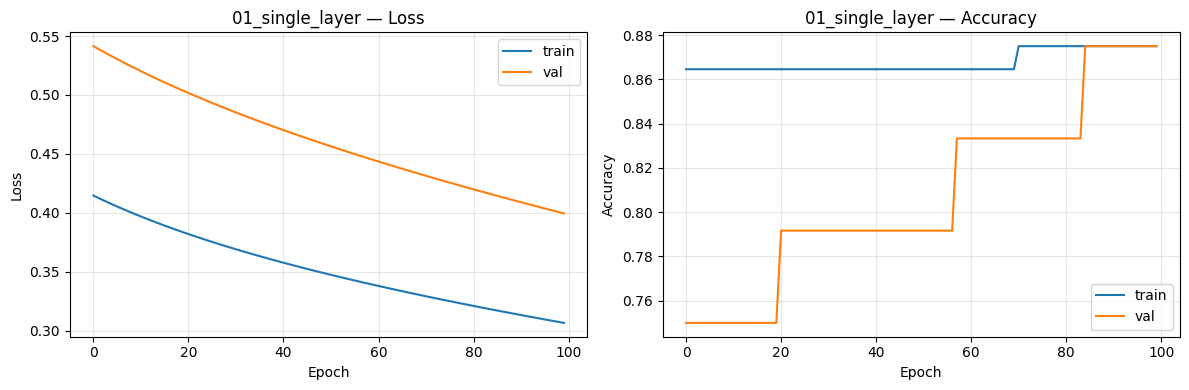

In [17]:
plot_training_curves(history, variant_name='01_single_layer')


## 7. Evaluasi di test set

In [18]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='01_single_layer')
save_history(history, variant_name='01_single_layer')
summary



📊 01_single_layer
   Test loss:     0.4380
   Test accuracy: 0.8000
   Jumlah parameter: 15
✅ History tersimpan di: results/01_single_layer.csv


{'variant': '01_single_layer',
 'test_loss': 0.4379805028438568,
 'test_accuracy': 0.800000011920929,
 'n_params': 15}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Berapa total jumlah parameter model ini? Bandingkan dengan varian multi-layer.
2. Menurutmu, apakah model ini cukup ekspresif untuk Iris? Mengapa?
3. Jika dataset diganti dengan yang non-linear separable (mis. XOR), apa prediksimu?


_Tulis jawabanmu di sini..._